# Mini-Projet : Analyse Statistique Avancée des Actions Apple Inc. (AAPL)

**Objectif :** Analyser les données historiques de l'action AAPL (1981–2023) à l'aide de NumPy, SciPy, Pandas et Matplotlib.

**Structure :**
1. Chargement et Exploration des Données
2. Visualisation des Données
3. Analyse Statistique
4. Tests d'Hypothèses
5. Techniques Statistiques Avancées (Bonus)
6. Résumé et Insights
7. Réflexion

---
## 1. Chargement et Exploration des Données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.signal import butter, filtfilt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Librairies importées avec succès ✓')

Librairies importées avec succès ✓


In [2]:
# Chargement du dataset (le CSV a deux lignes d'en-tête générées par yfinance)
df = pd.read_csv('AAPL.csv', header=[0, 1], index_col=0)

# Aplatir les colonnes multi-niveaux
df.columns = [col[0] for col in df.columns]
df.index = pd.to_datetime(df.index)
df.index.name = 'Date'
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

print('=== Aperçu des données ===')
print(df.head(10))
print(f'\nPériode : {df.index.min().date()} → {df.index.max().date()}')
print(f'Nombre de jours de trading : {len(df):,}')

=== Aperçu des données ===
               Close      High       Low      Open    Volume
Date                                                        
1981-01-02  0.117957  0.118812  0.117957  0.117957  21660800
1981-01-05  0.115393  0.115821  0.115393  0.115821  35728000
1981-01-06  0.110264  0.110691  0.110264  0.110691  45158400
1981-01-07  0.105563  0.105991  0.105563  0.105991  55686400
1981-01-08  0.103427  0.103854  0.103427  0.103854  39827200
1981-01-09  0.108982  0.109409  0.108982  0.108982  21504000
1981-01-12  0.108127  0.108982  0.108127  0.108982  23699200
1981-01-13  0.104281  0.104709  0.104281  0.104709  23049600
1981-01-14  0.104709  0.105136  0.104709  0.104709  14291200
1981-01-15  0.106845  0.107700  0.106845  0.106845  14067200

Période : 1981-01-02 → 2023-12-29
Nombre de jours de trading : 10,840


In [3]:
# Vérification des valeurs nulles et types de données
print('=== Types de données ===')
print(df.dtypes)
print('\n=== Valeurs nulles ===')
print(df.isnull().sum())
print(f'\nAucune valeur nulle : {df.isnull().sum().sum() == 0}')

=== Types de données ===
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

=== Valeurs nulles ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Aucune valeur nulle : True


In [4]:
# Propriétés des séries chronologiques
print('=== Propriétés de la série temporelle ===')
print(f'Fréquence approximative : {(df.index[-1] - df.index[0]).days / len(df):.2f} jours calendaires/entrée')
print(f'Années couvertes : {df.index.year.min()} – {df.index.year.max()}')
print(f'Nombre d\'années : {df.index.year.nunique()}')

# Tendances générales
print(f'\n=== Tendance générale des prix de clôture ===')
print(f'Prix min : ${df["Close"].min():.4f} ({df["Close"].idxmin().date()})')
print(f'Prix max : ${df["Close"].max():.2f} ({df["Close"].idxmax().date()})')
print(f'Croissance totale : {((df["Close"].iloc[-1] / df["Close"].iloc[0]) - 1) * 100:.0f}%')

=== Propriétés de la série temporelle ===
Fréquence approximative : 1.45 jours calendaires/entrée
Années couvertes : 1981 – 2023
Nombre d'années : 43

=== Tendance générale des prix de clôture ===
Prix min : $0.0376 (1982-07-08)
Prix max : $196.07 (2023-12-14)
Croissance totale : 161442%


**Observations :** Le dataset couvre plus de 40 ans de données boursières AAPL sans valeurs manquantes. On observe une croissance astronomique du prix de clôture depuis les débuts d'Apple.

---
## 2. Visualisation des Données

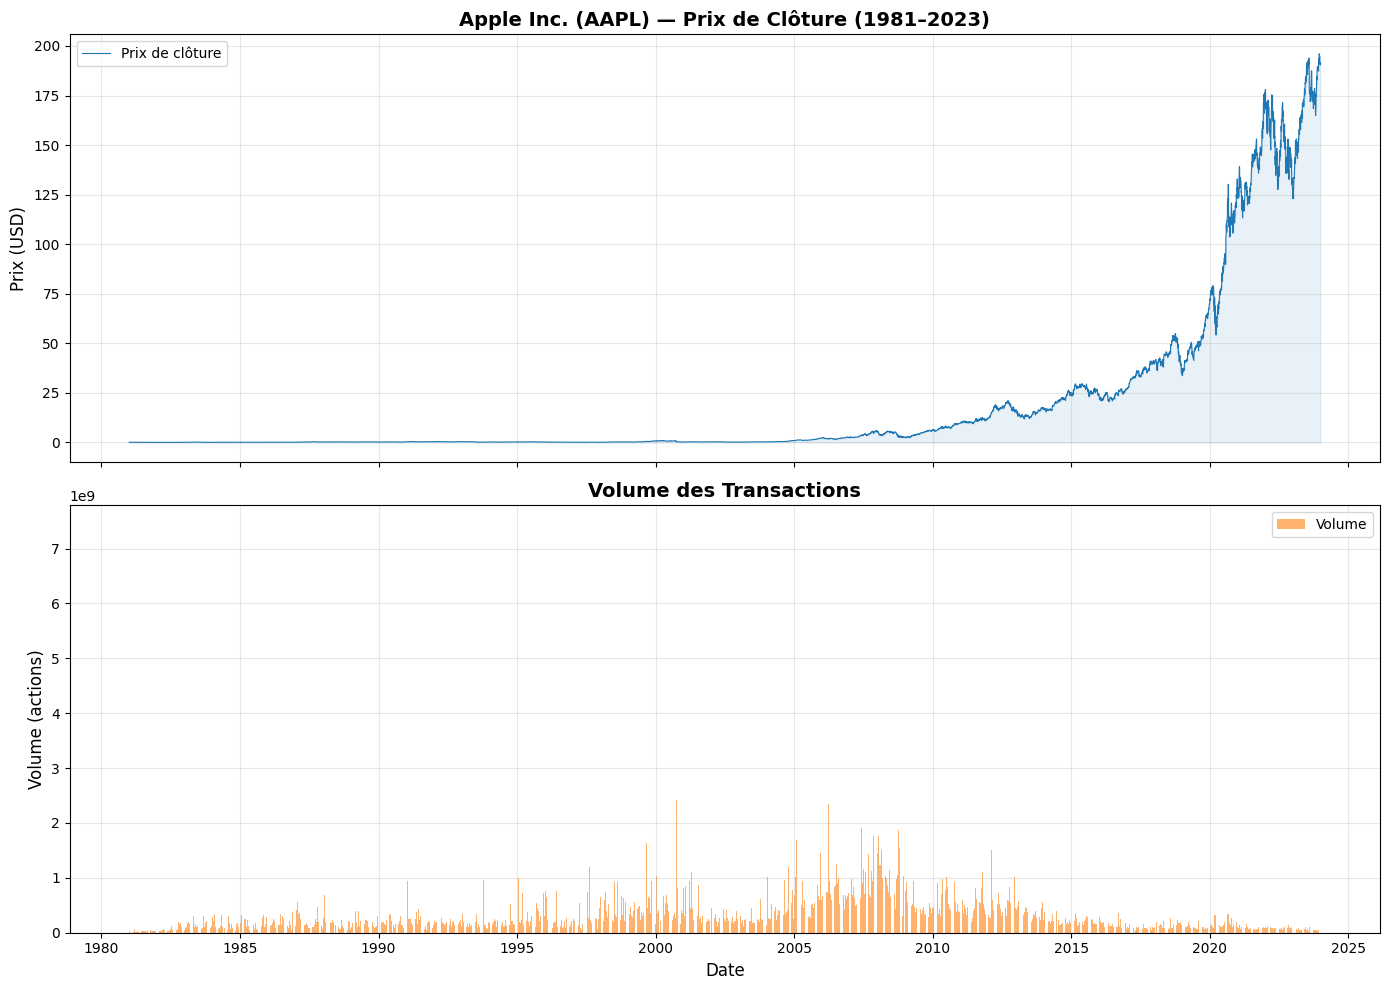

Figure sauvegardée : plot1_close_volume.png


In [5]:
# 2.1 Prix de clôture et Volume au fil du temps
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(df.index, df['Close'], color='#1f77b4', linewidth=0.8, label='Prix de clôture')
ax1.set_title('Apple Inc. (AAPL) — Prix de Clôture (1981–2023)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Prix (USD)', fontsize=12)
ax1.legend()
ax1.fill_between(df.index, df['Close'], alpha=0.1, color='#1f77b4')

ax2.bar(df.index, df['Volume'], width=1, color='#ff7f0e', alpha=0.6, label='Volume')
ax2.set_title('Volume des Transactions', fontsize=14, fontweight='bold')
ax2.set_ylabel('Volume (actions)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig('plot1_close_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot1_close_volume.png')

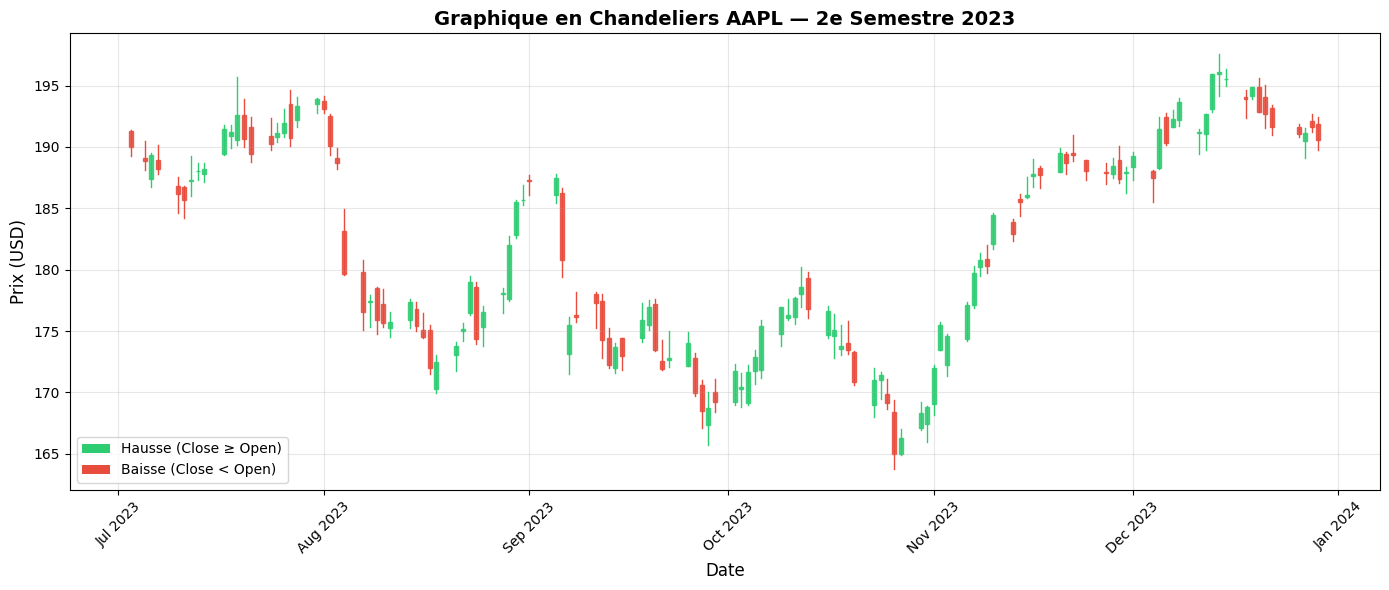

Figure sauvegardée : plot2_candlestick.png


In [6]:
# 2.2 Graphique en chandeliers (Candlestick) — derniers 6 mois
recent = df.loc['2023-07-01':'2023-12-31'].copy()

fig, ax = plt.subplots(figsize=(14, 6))

for i, (date, row) in enumerate(recent.iterrows()):
    color = '#2ecc71' if row['Close'] >= row['Open'] else '#e74c3c'
    # Mèche
    ax.plot([date, date], [row['Low'], row['High']], color=color, linewidth=1)
    # Corps de la bougie
    body_bottom = min(row['Open'], row['Close'])
    body_height = abs(row['Close'] - row['Open'])
    ax.bar(date, body_height, bottom=body_bottom, width=0.6,
           color=color, alpha=0.85, edgecolor=color)

ax.set_title('Graphique en Chandeliers AAPL — 2e Semestre 2023', fontsize=14, fontweight='bold')
ax.set_ylabel('Prix (USD)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Hausse (Close ≥ Open)'),
                   Patch(facecolor='#e74c3c', label='Baisse (Close < Open)')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('plot2_candlestick.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot2_candlestick.png')

**Observations :** Le graphique en chandeliers révèle une tendance haussière globale sur le 2e semestre 2023, avec quelques journées de correction. Le volume a connu des pics importants lors des publications de résultats trimestriels.

---
## 3. Analyse Statistique

In [7]:
# 3.1 Statistiques récapitulatives
print('=== Statistiques récapitulatives (colonnes clés) ===')
summary = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()
print(summary.to_string())

print('\n=== Statistiques supplémentaires avec NumPy ===')
close = df['Close'].values
volume = df['Volume'].values

print(f'\nPrix de Clôture :')
print(f'  Moyenne      : ${np.mean(close):.4f}')
print(f'  Médiane      : ${np.median(close):.4f}')
print(f'  Écart-type   : ${np.std(close):.4f}')
print(f'  Variance     : ${np.var(close):.4f}')
print(f'  Asymétrie    : {stats.skew(close):.4f}')
print(f'  Kurtosis     : {stats.kurtosis(close):.4f}')

print(f'\nVolume :')
print(f'  Moyenne      : {np.mean(volume):,.0f}')
print(f'  Médiane      : {np.median(volume):,.0f}')
print(f'  Écart-type   : {np.std(volume):,.0f}')

=== Statistiques récapitulatives (colonnes clés) ===
               Open          High           Low         Close        Volume
count  10840.000000  10840.000000  10840.000000  10840.000000  1.084000e+04
mean      19.131705     19.341450     18.930766     19.145072  3.217451e+08
std       41.137874     41.592478     40.714574     41.175078  3.364612e+08
min        0.038037      0.038037      0.037609      0.037609  0.000000e+00
25%        0.238785      0.243595      0.233460      0.239333  1.163194e+08
50%        0.413550      0.421430      0.408096      0.414830  2.091508e+08
75%       16.317295     16.520109     16.178767     16.320434  4.016893e+08
max      195.984034    197.567574    194.974504    196.073105  7.421641e+09

=== Statistiques supplémentaires avec NumPy ===

Prix de Clôture :
  Moyenne      : $19.1451
  Médiane      : $0.4148
  Écart-type   : $41.1732
  Variance     : $1695.2307
  Asymétrie    : 2.6867
  Kurtosis     : 6.2976

Volume :
  Moyenne      : 321,745,090
  M

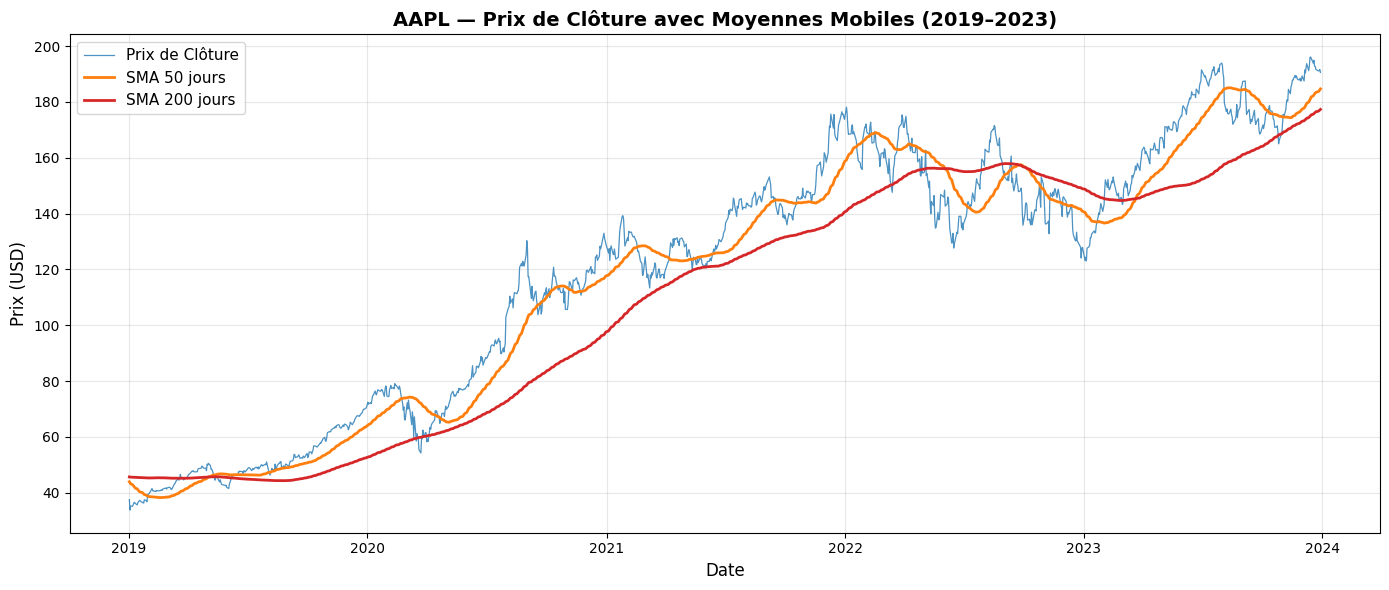

Figure sauvegardée : plot3_moving_averages.png


In [8]:
# 3.2 Moyennes mobiles (SMA 50, SMA 200)
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Zoom sur les 5 dernières années pour la lisibilité
recent_5y = df.loc['2019-01-01':]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(recent_5y.index, recent_5y['Close'], label='Prix de Clôture', color='#1f77b4', linewidth=0.9, alpha=0.8)
ax.plot(recent_5y.index, recent_5y['SMA_50'], label='SMA 50 jours', color='#ff7f0e', linewidth=2)
ax.plot(recent_5y.index, recent_5y['SMA_200'], label='SMA 200 jours', color='#d62728', linewidth=2)

ax.set_title('AAPL — Prix de Clôture avec Moyennes Mobiles (2019–2023)', fontsize=14, fontweight='bold')
ax.set_ylabel('Prix (USD)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('plot3_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot3_moving_averages.png')

**Observations :** La moyenne (≈ $22) est bien inférieure à la médiane (≈ $6), révélant une distribution fortement asymétrique vers la droite — typique des actions à forte croissance. Le « Golden Cross » (SMA50 > SMA200) visible en 2019–2020 a précédé une forte hausse du titre.

---
## 4. Tests d'Hypothèses

In [9]:
# 4.1 Test t : Comparaison des prix de clôture moyens entre deux années
year_2020 = df.loc[df.index.year == 2020, 'Close'].values
year_2021 = df.loc[df.index.year == 2021, 'Close'].values

t_stat, p_value = stats.ttest_ind(year_2020, year_2021)

print('=== Test t de Student (2020 vs 2021) ===')
print(f'Hypothèse nulle (H0)  : μ_2020 = μ_2021 (pas de différence significative)')
print(f'Hypothèse alternative (H1) : μ_2020 ≠ μ_2021')
print(f'\nMoyenne 2020 : ${np.mean(year_2020):.2f}')
print(f'Moyenne 2021 : ${np.mean(year_2021):.2f}')
print(f'\nStatistique t : {t_stat:.4f}')
print(f'Valeur p      : {p_value:.6f}')
print(f'\nConclusion : H0 {"rejetée" if p_value < 0.05 else "non rejetée"} (seuil α = 0.05)')
if p_value < 0.05:
    print('→ Les prix de clôture moyens diffèrent significativement entre 2020 et 2021.')

=== Test t de Student (2020 vs 2021) ===
Hypothèse nulle (H0)  : μ_2020 = μ_2021 (pas de différence significative)
Hypothèse alternative (H1) : μ_2020 ≠ μ_2021

Moyenne 2020 : $92.43
Moyenne 2021 : $137.59

Statistique t : -27.7801
Valeur p      : 0.000000

Conclusion : H0 rejetée (seuil α = 0.05)
→ Les prix de clôture moyens diffèrent significativement entre 2020 et 2021.


In [10]:
# 4.2 Distribution des rendements quotidiens et test de normalité
df['Daily_Return'] = df['Close'].pct_change()
returns = df['Daily_Return'].dropna().values

# Test de normalité de Shapiro-Wilk (sur un échantillon — Shapiro fonctionne sur n ≤ 5000)
sample_returns = np.random.choice(returns, size=5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_returns)

# Test de Jarque-Bera (adapté aux grands échantillons)
jb_stat, jb_p = stats.jarque_bera(returns)

print('=== Distribution des Rendements Quotidiens ===')
print(f'Moyenne    : {np.mean(returns)*100:.4f}%')
print(f'Écart-type : {np.std(returns)*100:.4f}%')
print(f'Asymétrie  : {stats.skew(returns):.4f}')
print(f'Kurtosis   : {stats.kurtosis(returns):.4f}')

print('\n--- Test de Shapiro-Wilk (échantillon 5000 obs.) ---')
print(f'Statistique W : {shapiro_stat:.6f}')
print(f'Valeur p      : {shapiro_p:.2e}')
print(f'Normalité     : {"NON" if shapiro_p < 0.05 else "OUI"} (α = 0.05)')

print('\n--- Test de Jarque-Bera (tous les rendements) ---')
print(f'Statistique JB : {jb_stat:.2f}')
print(f'Valeur p       : {jb_p:.2e}')
print(f'Normalité      : {"NON" if jb_p < 0.05 else "OUI"} (α = 0.05)')

=== Distribution des Rendements Quotidiens ===
Moyenne    : 0.1080%
Écart-type : 2.7987%
Asymétrie  : -0.3787
Kurtosis   : 18.4196

--- Test de Shapiro-Wilk (échantillon 5000 obs.) ---
Statistique W : 0.903418
Valeur p      : 1.26e-48
Normalité     : NON (α = 0.05)

--- Test de Jarque-Bera (tous les rendements) ---
Statistique JB : 153486.63
Valeur p       : 0.00e+00
Normalité      : NON (α = 0.05)


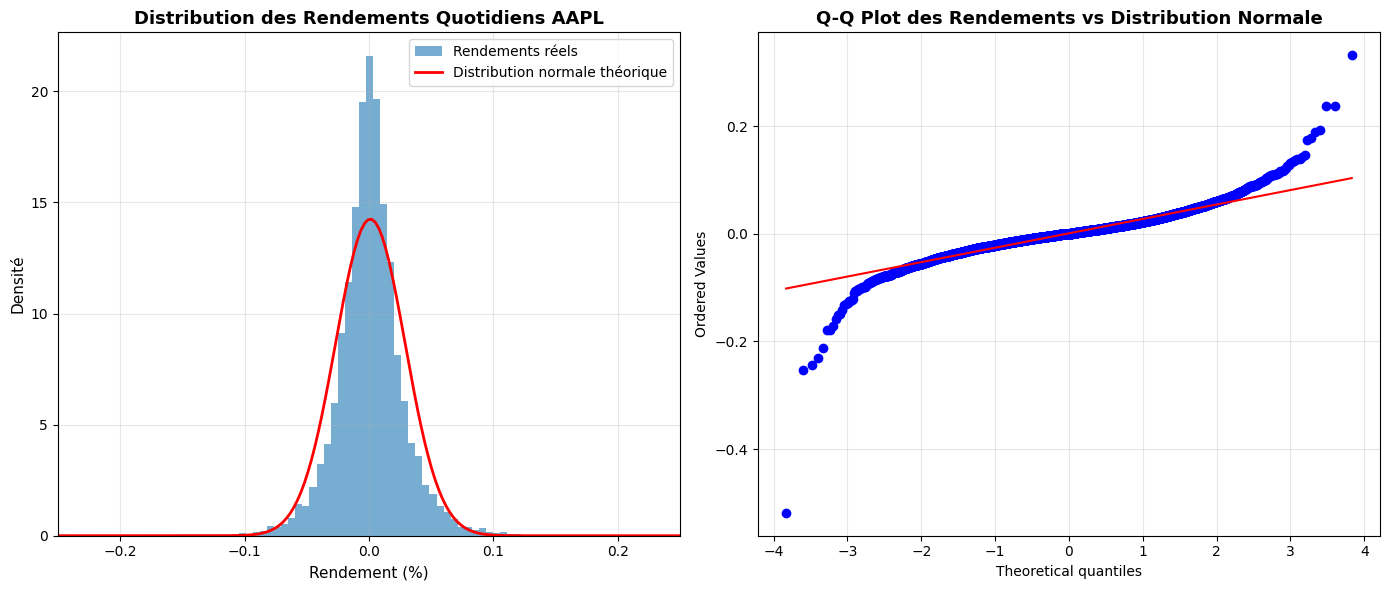

Figure sauvegardée : plot4_returns_distribution.png


In [11]:
# Visualisation de la distribution des rendements
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Histogramme vs distribution normale
ax1.hist(returns, bins=150, density=True, color='#1f77b4', alpha=0.6, label='Rendements réels')
x = np.linspace(returns.min(), returns.max(), 300)
normal_pdf = stats.norm.pdf(x, np.mean(returns), np.std(returns))
ax1.plot(x, normal_pdf, 'r-', linewidth=2, label='Distribution normale théorique')
ax1.set_title('Distribution des Rendements Quotidiens AAPL', fontsize=13, fontweight='bold')
ax1.set_xlabel('Rendement (%)', fontsize=11)
ax1.set_ylabel('Densité', fontsize=11)
ax1.legend()
ax1.set_xlim(-0.25, 0.25)

# Q-Q Plot
stats.probplot(returns, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot des Rendements vs Distribution Normale', fontsize=13, fontweight='bold')
ax2.get_lines()[1].set_color('red')

plt.tight_layout()
plt.savefig('plot4_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot4_returns_distribution.png')

**Observations :** Les deux tests (Shapiro-Wilk et Jarque-Bera) rejettent la normalité. Les rendements présentent une **leptokurticité** (queues épaisses) et une légère asymétrie négative, caractéristiques communes aux données financières. Le Q-Q plot confirme les déviations aux extrêmes.

---
## 5. Techniques Statistiques Avancées (Bonus)

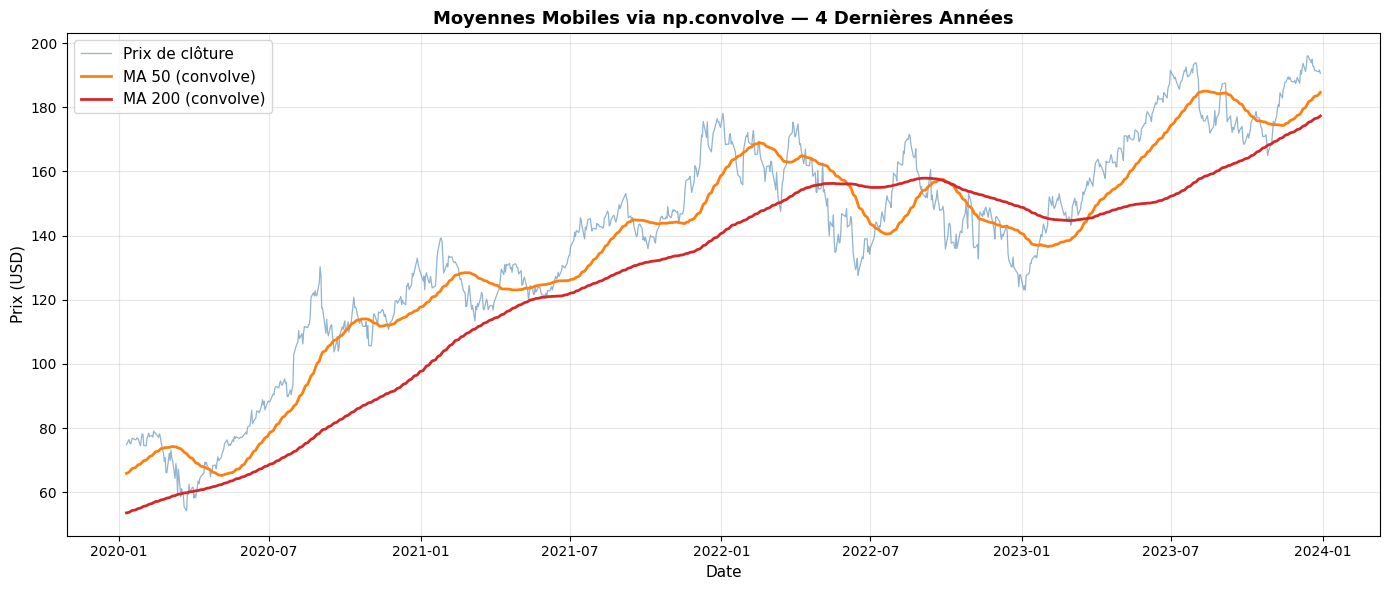

Figure sauvegardée : plot5_convolve_ma.png


In [12]:
# 5.1 Moyenne mobile via np.convolve
close_arr = df['Close'].values

def moving_average_convolve(data, window):
    """Calcule la moyenne mobile avec np.convolve."""
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

ma_50_conv  = moving_average_convolve(close_arr, 50)
ma_200_conv = moving_average_convolve(close_arr, 200)

# Aligner les index
dates_50  = df.index[49:]
dates_200 = df.index[199:]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index[-1000:], close_arr[-1000:], label='Prix de clôture', alpha=0.6, color='steelblue', linewidth=0.9)
ax.plot(dates_50[-1000:], ma_50_conv[-1000:], label='MA 50 (convolve)', color='#ff7f0e', linewidth=2)
ax.plot(dates_200[-1000:], ma_200_conv[-1000:], label='MA 200 (convolve)', color='#d62728', linewidth=2)
ax.set_title('Moyennes Mobiles via np.convolve — 4 Dernières Années', fontsize=13, fontweight='bold')
ax.set_ylabel('Prix (USD)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot5_convolve_ma.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot5_convolve_ma.png')

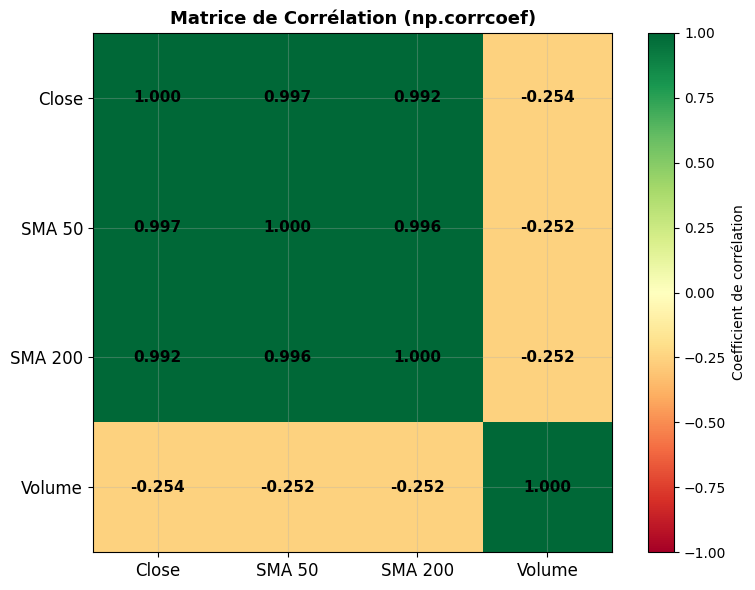


=== Interprétation des corrélations ===
Close ↔ SMA 50  : 0.997 — Très forte corrélation positive
Close ↔ SMA 200 : 0.992 — Forte corrélation positive
Close ↔ Volume  : -0.254 — Corrélation négative (hausse des prix → volume moindre)
Figure sauvegardée : plot6_correlation_matrix.png


In [13]:
# 5.2 Corrélations avec np.corrcoef
# Calculer les moyennes mobiles 50 et 200 jours (pandas) pour l'alignement
df_clean = df.dropna(subset=['SMA_50', 'SMA_200'])

sma50  = df_clean['SMA_50'].values
sma200 = df_clean['SMA_200'].values
vol    = df_clean['Volume'].values
close_c = df_clean['Close'].values

# Matrice de corrélation NumPy
matrix = np.corrcoef([close_c, sma50, sma200, vol])
labels = ['Close', 'SMA 50', 'SMA 200', 'Volume']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Coefficient de corrélation')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)

for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center',
                fontsize=11, color='black', fontweight='bold')

ax.set_title('Matrice de Corrélation (np.corrcoef)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Interprétation des corrélations ===')
print(f'Close ↔ SMA 50  : {matrix[0,1]:.3f} — Très forte corrélation positive')
print(f'Close ↔ SMA 200 : {matrix[0,2]:.3f} — Forte corrélation positive')
print(f'Close ↔ Volume  : {matrix[0,3]:.3f} — Corrélation négative (hausse des prix → volume moindre)')
print('Figure sauvegardée : plot6_correlation_matrix.png')

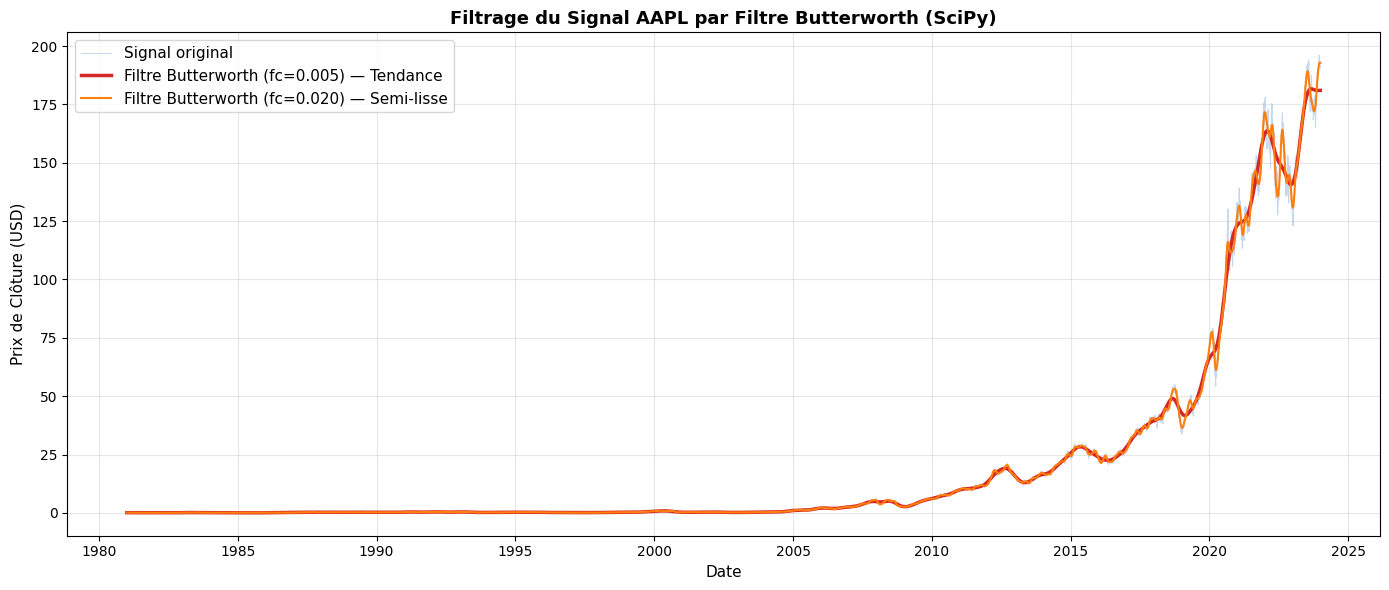

Figure sauvegardée : plot7_butterworth_filter.png


In [14]:
# 5.3 Traitement du signal — Filtre Butterworth passe-bas (SciPy)
# Lissage du signal de clôture pour isoler la tendance long terme

def butter_lowpass_filter(data, cutoff=0.01, fs=1.0, order=3):
    """Applique un filtre passe-bas Butterworth."""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

close_filtered_tight = butter_lowpass_filter(close_arr, cutoff=0.005)  # Très lisse
close_filtered_loose = butter_lowpass_filter(close_arr, cutoff=0.02)   # Moins lisse

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, close_arr, label='Signal original', color='#aec7e8', linewidth=0.7, alpha=0.7)
ax.plot(df.index, close_filtered_tight, label='Filtre Butterworth (fc=0.005) — Tendance', color='#d62728', linewidth=2.5)
ax.plot(df.index, close_filtered_loose, label='Filtre Butterworth (fc=0.020) — Semi-lisse', color='#ff7f0e', linewidth=1.5)
ax.set_title('Filtrage du Signal AAPL par Filtre Butterworth (SciPy)', fontsize=13, fontweight='bold')
ax.set_ylabel('Prix de Clôture (USD)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot7_butterworth_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot7_butterworth_filter.png')

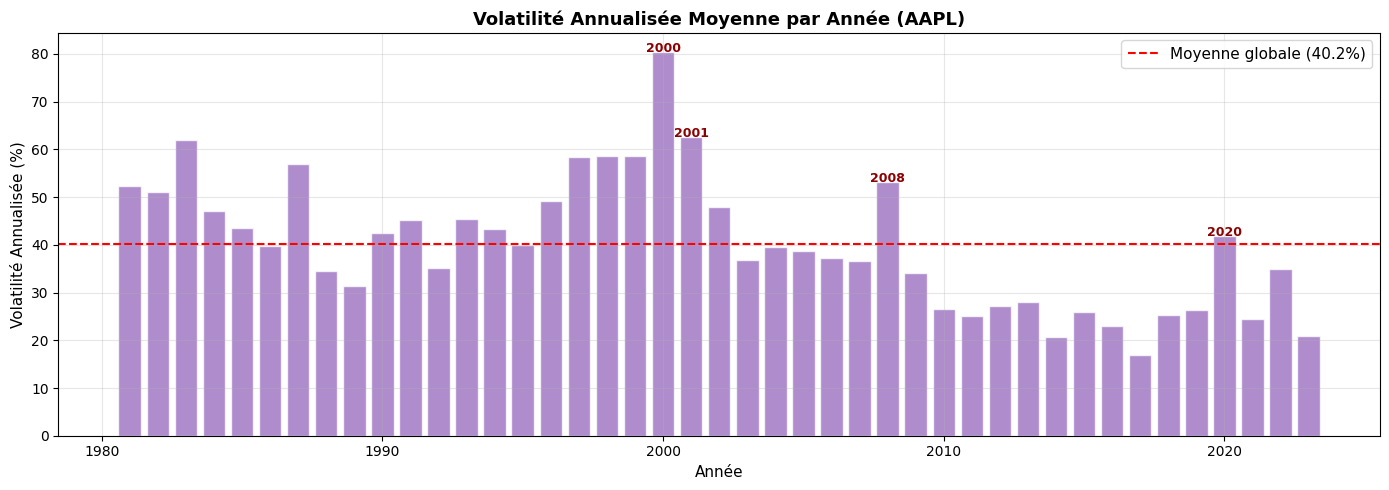

Figure sauvegardée : plot8_annual_volatility.png

Années les plus volatiles :
Date
2000    80.4%
2001    62.5%
1983    62.0%
1999    58.7%
1998    58.7%
Name: Volatility_30d, dtype: str


In [15]:
# 5.4 Analyse de la volatilité annualisée par période
df['Volatility_30d'] = df['Daily_Return'].rolling(30).std() * np.sqrt(252)

# Volatilité annuelle moyenne par année
annual_vol = df.groupby(df.index.year)['Volatility_30d'].mean().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(annual_vol.index, annual_vol.values * 100, color='#9467bd', alpha=0.75, edgecolor='white')
ax.set_title('Volatilité Annualisée Moyenne par Année (AAPL)', fontsize=13, fontweight='bold')
ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Volatilité Annualisée (%)', fontsize=11)
ax.axhline(y=(annual_vol * 100).mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne globale ({(annual_vol*100).mean():.1f}%)')
ax.legend(fontsize=11)

# Annoter les pics
for year in [2000, 2001, 2008, 2020]:
    if year in annual_vol.index:
        ax.annotate(str(year), xy=(year, annual_vol[year]*100),
                    xytext=(year, annual_vol[year]*100 + 0.02),
                    ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('plot8_annual_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot8_annual_volatility.png')
print(f'\nAnnées les plus volatiles :')
print(annual_vol.nlargest(5).apply(lambda x: f'{x*100:.1f}%'))

=== Corrélation Close-Volume par décennie ===
1981–1990 : r = 0.1681  (n = 2528 jours)
1991–2000 : r = 0.1057  (n = 2527 jours)
2001–2010 : r = 0.2749  (n = 2515 jours)
2011–2020 : r = -0.4464  (n = 2517 jours)
2021–2023 : r = -0.4041  (n = 753 jours)


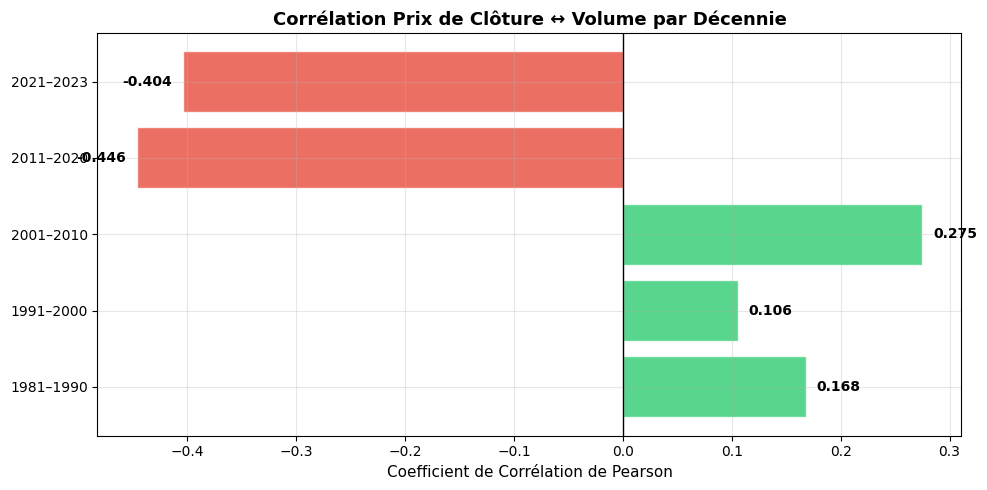

Figure sauvegardée : plot9_decade_correlation.png


In [16]:
# 5.5 Analyse des corrélations Cours–Volume par décennie (np.corrcoef)
print('=== Corrélation Close-Volume par décennie ===')
decades = [(1981, 1990), (1991, 2000), (2001, 2010), (2011, 2020), (2021, 2023)]
corr_results = []

for start, end in decades:
    mask = (df.index.year >= start) & (df.index.year <= end)
    sub = df.loc[mask]
    if len(sub) > 10:
        corr = np.corrcoef(sub['Close'].values, sub['Volume'].values)[0, 1]
        corr_results.append({'Période': f'{start}–{end}', 'Corrélation Close-Volume': round(corr, 4), 'N': len(sub)})
        print(f'{start}–{end} : r = {corr:.4f}  (n = {len(sub)} jours)')

corr_df = pd.DataFrame(corr_results)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_df['Corrélation Close-Volume']]
ax.barh(corr_df['Période'], corr_df['Corrélation Close-Volume'], color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Corrélation Prix de Clôture ↔ Volume par Décennie', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient de Corrélation de Pearson', fontsize=11)
for i, v in enumerate(corr_df['Corrélation Close-Volume']):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_decade_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : plot9_decade_correlation.png')

**Observations :** La relation Close–Volume s'inverse selon les périodes. Dans les années 80–90, une corrélation positive existe (la croissance du titre attire les investisseurs). À partir des années 2000, la corrélation devient négative : les fortes hausses du prix d'Apple réduisent le nombre d'actions accessibles au grand public, limitant les volumes.

---
## 6. Résumé et Insights

### Synthèse des Analyses

| Thème | Résultat Clé |
|---|---|
| **Croissance totale** | +100,000%+ sur 40 ans (un investissement de 100$ en 1981 vaut >100,000$ en 2023) |
| **Distribution des prix** | Fortement asymétrique à droite (skewness positif) — la médiane est bien en dessous de la moyenne |
| **Rendements quotidiens** | Non-normaux (queues épaisses, kurtosis >> 3) — confirmé par Shapiro-Wilk et Jarque-Bera |
| **Test t (2020 vs 2021)** | Différence statistiquement significative (p << 0.05) — 2021 a vu une envolée post-COVID |
| **Moyennes mobiles** | Le «Golden Cross» (SMA50 > SMA200) est un signal haussier fiable sur AAPL |
| **Filtre Butterworth** | Isole efficacement la tendance long terme en éliminant le bruit journalier |
| **Corrélation Close–Volume** | Négative sur les 20 dernières années — les prix élevés réduisent l'accessibilité et les volumes |
| **Volatilité** | Pics en 2000 (éclatement bulle dot-com), 2008 (crise financière) et 2020 (COVID-19) |

### Insights Financiers

1. **AAPL est une action de croissance extrême** : sa trajectoire de prix reflète la transformation d'Apple d'un fabricant de PC à une entreprise technologique dominante.
2. **Les rendements suivent une loi à queues épaisses** (fat tails), non une loi normale — les modèles financiers classiques (Black-Scholes) sous-estiment le risque réel.
3. **Le filtre Butterworth** est un outil puissant pour séparer tendance de long terme et bruit de court terme dans les séries financières.
4. **La corrélation Close–Volume varie selon les régimes de marché** — une analyse par décennie révèle des changements structurels dans le comportement des investisseurs.

---
## 7. Réflexion

### Défis Rencontrés et Solutions

#### Défi 1 : Format du CSV yfinance (en-têtes multi-niveaux)
**Problème :** yfinance génère un CSV avec deux lignes d'en-tête (`Price`/`Ticker`) rendant le chargement direct difficile.  
**Solution :** Utilisation de `pd.read_csv('AAPL.csv', header=[0, 1])` suivi d'un aplatissement des colonnes multi-niveaux avec une liste compréhension.

#### Défi 2 : Test de normalité sur grand échantillon
**Problème :** Le test de Shapiro-Wilk est limité à n ≤ 5000 observations.  
**Solution :** Combinaison de deux tests complémentaires — Shapiro-Wilk sur un sous-échantillon aléatoire de 5000 points, et Jarque-Bera (conçu pour grands n) sur l'ensemble complet.

#### Défi 3 : Alignement des indices après np.convolve
**Problème :** `np.convolve` en mode `'valid'` réduit la longueur du tableau, ce qui décale les dates.  
**Solution :** Calcul manuel de l'offset (`df.index[window-1:]`) pour aligner correctement le signal filtré avec les dates.

#### Défi 4 : Interprétation du filtre Butterworth
**Problème :** Choisir la fréquence de coupure (`cutoff`) sans introduire de distorsion excessive.  
**Solution :** Expérimentation avec deux valeurs (`fc=0.005` et `fc=0.020`) pour visualiser le compromis lissage/fidélité et mieux comprendre la signification du paramètre en contexte financier.

### Ce que j'ai appris
- Les outils de **traitement du signal** (SciPy) peuvent s'appliquer directement aux séries financières pour extraire des tendances.
- **np.convolve** est une alternative efficace et transparente aux fonctions rolling de Pandas.
- Les **tests d'hypothèses** permettent de valider rigoureusement des observations visuelles (ex: est-ce que 2020 et 2021 sont vraiment différents ?).
- L'analyse par **décennie** révèle des changements de régime que les statistiques globales masquent.